# A Comparative and Explainable Study of ML and DL Models for Time-Series Air Quality Prediction in Dublin
**Student:** Srinivasan Dillikumar |**ID:** 24285951 | **Module:** H9MLAI Machine Learning | **Year:** 2025–2026

## 1. Imports & Setup

In [1]:
# Required packages: xgboost, shap, tensorflow
# Install using: pip install -r requirements.txt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle, time, os, sys
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sklearn
import xgboost as xgb
import shap
import tensorflow as tf

print('Setup complete.')

Setup complete.


In [2]:
print("Python   :", sys.version)
print("NumPy    :", np.__version__)
print("Pandas   :", pd.__version__)
print("sklearn  :", sklearn.__version__)
print("XGBoost  :", xgb.__version__)
print("SHAP     :", shap.__version__)
print("Tensor Flow:", tf.__version__)

Python   : 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
NumPy    : 2.3.5
Pandas   : 2.3.3
sklearn  : 1.7.2
XGBoost  : 3.2.0
SHAP     : 0.51.0
Tensor Flow: 2.21.0


## 2. Data Loading

In [3]:
DATA_DIR = './'

def parse_pm(fname):
    """Parse daily PM2.5/PM10 file (latin-1, 6 header rows, multiple station columns)."""
    df = pd.read_csv(DATA_DIR + fname, skiprows=6, header=0, encoding='latin-1')
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
    df = df.dropna(subset=[date_col]).set_index(date_col)
    pm25_cols = [c for c in df.columns if 'PM2.5' in str(c) or 'PM2' in str(c)]
    pm10_cols = [c for c in df.columns if 'PM10'  in str(c) and c not in pm25_cols]
    for c in pm25_cols + pm10_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    result = pd.DataFrame(index=df.index)
    result['PM25'] = df[pm25_cols].mean(axis=1) if pm25_cols else np.nan
    result['PM10'] = df[pm10_cols].mean(axis=1) if pm10_cols else np.nan
    return result

def parse_nono2(fname, keyword, new_name):
    """Parse hourly NO/NO2 file — averages all station columns, aggregates to daily."""
    df = pd.read_csv(DATA_DIR + fname, skiprows=6, header=0)
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
    df = df.dropna(subset=[date_col])
    val_cols = [c for c in df.columns if keyword in str(c)]
    for c in val_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['_mean'] = df[val_cols].mean(axis=1)
    return df.groupby(date_col)['_mean'].mean().rename(new_name)

def parse_hourly(fname, col_name, new_name):
    """Parse hourly SO2/CO file — aggregates first station column to daily mean."""
    df = pd.read_csv(DATA_DIR + fname, skiprows=6, header=0)
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
    df = df.dropna(subset=[date_col])
    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
    return df.groupby(date_col)[col_name].mean().rename(new_name)

# Load and combine 2011 + 2012
pm_all  = pd.concat([parse_pm('dublin-city-council-pm10-2.5-2011.csv'),
                     parse_pm('dublin-city-council-pm10-2.5-2012.csv')]).sort_index()
no2_all = pd.concat([parse_nono2('dublin-city-council-no-no2-2011.csv', 'NO2 ug/m3', 'NO2'),
                     parse_nono2('dublin-city-council-no-no2-2012.csv', 'NO2 ug/m3', 'NO2')]).sort_index()
no_all  = pd.concat([parse_nono2('dublin-city-council-no-no2-2011.csv', 'NO ug/m3',  'NO'),
                     parse_nono2('dublin-city-council-no-no2-2012.csv', 'NO ug/m3',  'NO') ]).sort_index()
so2_all = pd.concat([parse_hourly('dublin-city-council-so2-2011.csv', 'SO2 ug/m3', 'SO2'),
                     parse_hourly('dublin-city-council-so2-2012.csv', 'SO2 ug/m3', 'SO2')]).sort_index()
co_all  = pd.concat([parse_hourly('dublin-city-council-co-2011.csv',  'CO mg/m3',  'CO'),
                     parse_hourly('dublin-city-council-co-2012.csv',  'CO mg/m3',  'CO') ]).sort_index()

# Merge on date index
df = pm_all.copy()
for s in [no2_all, no_all, so2_all, co_all]:
    df = df.join(s, how='left')
df = df.sort_index()
df = df[(df.index >= '2011-01-01') & (df.index <= '2012-12-31')]

print(f'Shape: {df.shape}  |  Date range: {df.index.min().date()} → {df.index.max().date()}')
df.head()

Shape: (732, 6)  |  Date range: 2011-01-01 → 2012-12-31


,PM25,PM10,NO2,NO,SO2,CO
Date,,,,,,
2011-01-01,16.90,18.366667,27.772917,6.325000,0.882609,0.060870
2011-01-02,10.75,13.433333,30.310417,6.054167,0.500000,0.037500
2011-01-03,21.55,21.166667,44.037500,24.808333,0.979167,0.062500
2011-01-04,8.70,10.166667,26.418750,10.685417,0.404167,0.019048
2011-01-05,9.20,10.950000,37.381250,16.066667,0.659091,0.037500


## 3. Preprocessing

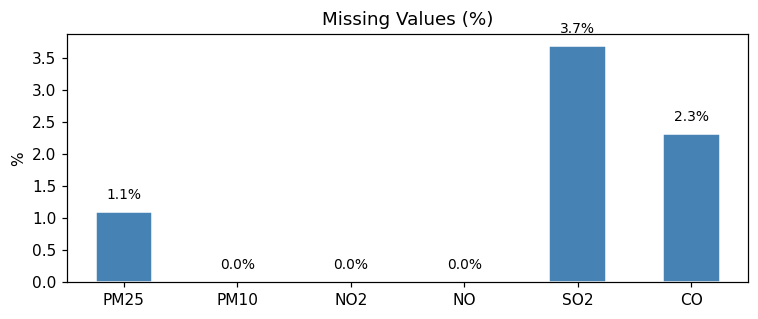

In [4]:
# Missing value summary
miss = df.isnull().sum() / len(df) * 100
fig, ax = plt.subplots(figsize=(7, 3))
miss.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Missing Values (%)')
ax.set_ylabel('%')
ax.set_xticklabels(miss.index, rotation=0)
for i, v in enumerate(miss): ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_missing.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Clip negatives, winsorise NO outlier, forward-fill ≤3 days, drop missing target
for col in ['SO2', 'CO', 'NO']:
    df[col] = df[col].clip(lower=0)
df['NO'] = df['NO'].clip(upper=df['NO'].quantile(0.99))
df = df.ffill(limit=3)
df = df.dropna(subset=['PM25'])
df = df.fillna(df.median(numeric_only=True))

print(f'Cleaned shape: {df.shape}  |  Remaining NaN: {df.isnull().sum().sum()}')
df.describe().round(2)

Cleaned shape: (732, 6)  |  Remaining NaN: 0


,PM25,PM10,NO2,NO,SO2,CO
count,732.00,732.00,732.00,732.00,732.00,732.00
mean,9.54,13.35,29.03,21.67,0.66,0.09
std,8.34,9.07,14.31,31.34,1.42,0.10
min,0.70,2.20,5.05,0.00,0.00,0.00
25%,4.85,7.99,19.06,6.83,0.00,0.01
50%,6.98,10.70,25.50,10.88,0.35,0.08
75%,10.65,15.02,35.39,20.60,0.91,0.12
max,77.15,73.33,110.15,180.09,31.25,0.82


## 4. Exploratory Data Analysis

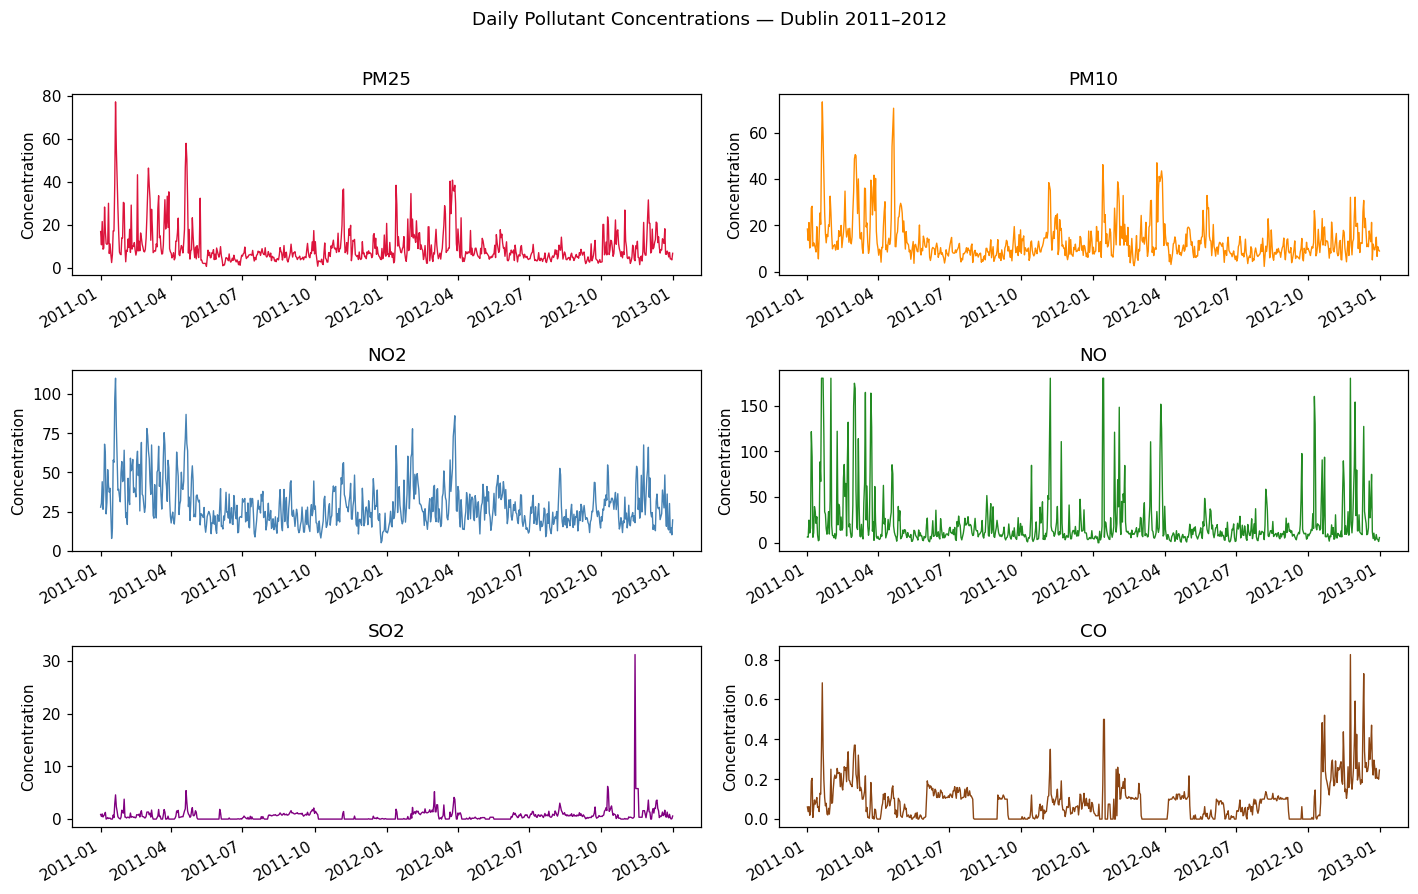

In [6]:
# Time series of all pollutants
cols_plot = ['PM25', 'PM10', 'NO2', 'NO', 'SO2', 'CO']
colors    = ['crimson', 'darkorange', 'steelblue', 'forestgreen', 'purple', 'saddlebrown']

fig, axes = plt.subplots(3, 2, figsize=(13, 8))
for ax, col, clr in zip(axes.flat, cols_plot, colors):
    df[col].plot(ax=ax, color=clr, linewidth=0.9)
    ax.set_title(col); ax.set_ylabel('Concentration'); ax.set_xlabel('')
plt.suptitle('Daily Pollutant Concentrations — Dublin 2011–2012', y=1.01)
plt.tight_layout()
plt.savefig('fig_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

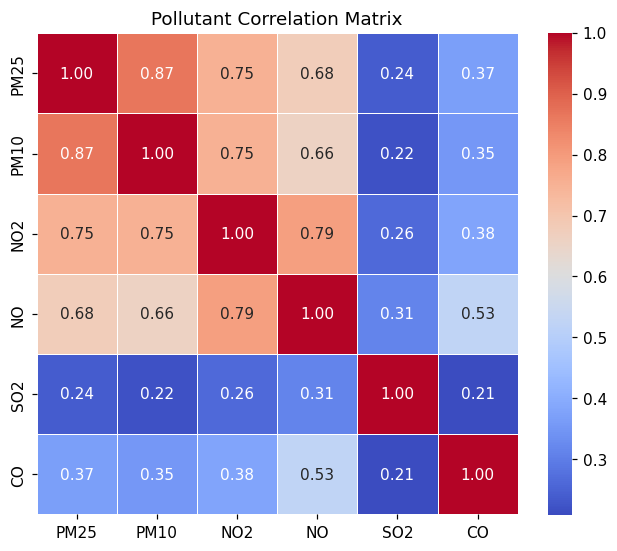

In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[cols_plot].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Pollutant Correlation Matrix')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

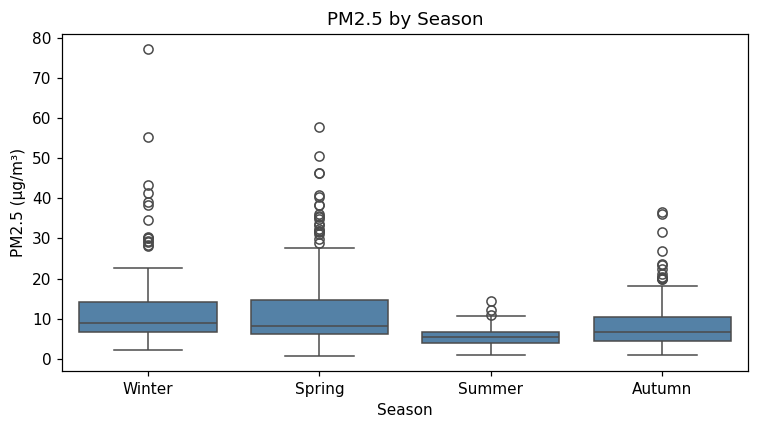

In [8]:
# Seasonal PM2.5 distribution
df['Season'] = df.index.month.map({
    12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'
})
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Season', y='PM25',
            order=['Winter','Spring','Summer','Autumn'], ax=ax, color='steelblue')
ax.set_title('PM2.5 by Season'); ax.set_ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('fig_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Engineering & Train/Val/Test Split

In [9]:
def engineer_features(df):
    f = df.copy()
    # Lag features
    for lag in [1, 2, 3, 7]:
        f[f'PM25_lag{lag}'] = f['PM25'].shift(lag)
    # Rolling statistics (shift by 1 to avoid leakage)
    for w in [3, 7]:
        f[f'PM25_roll{w}_mean'] = f['PM25'].shift(1).rolling(w).mean()
        f[f'PM25_roll{w}_std']  = f['PM25'].shift(1).rolling(w).std()
    # Co-pollutant lags
    for col in ['NO2', 'PM10', 'CO']:
        f[f'{col}_lag1'] = f[col].shift(1)
    # Temporal indicators
    f['DayOfWeek']  = f.index.dayofweek
    f['Month']      = f.index.month
    f['Season_num'] = f.index.month.map({
        12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3
    })
    return f.drop(columns=['Season'], errors='ignore').dropna()

df_feat   = engineer_features(df)
TARGET    = 'PM25'
FEAT_COLS = [c for c in df_feat.columns if c != TARGET]

print(f'Feature matrix: {df_feat.shape}  |  Features ({len(FEAT_COLS)}): {FEAT_COLS}')

Feature matrix: (725, 20)  |  Features (19): ['PM10', 'NO2', 'NO', 'SO2', 'CO', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag7', 'PM25_roll3_mean', 'PM25_roll3_std', 'PM25_roll7_mean', 'PM25_roll7_std', 'NO2_lag1', 'PM10_lag1', 'CO_lag1', 'DayOfWeek', 'Month', 'Season_num']


In [10]:
# Temporal split — no shuffling
X, y, dates = df_feat[FEAT_COLS].values, df_feat[TARGET].values, df_feat.index
n, t1, t2   = len(X), int(len(X)*0.70), int(len(X)*0.85)

X_tr, y_tr = X[:t1],   y[:t1]
X_va, y_va = X[t1:t2], y[t1:t2]
X_te, y_te = X[t2:],   y[t2:]

print(f'Train : {X_tr.shape}  ({dates[0].date()} → {dates[t1-1].date()})')
print(f'Val   : {X_va.shape}  ({dates[t1].date()} → {dates[t2-1].date()})')
print(f'Test  : {X_te.shape}  ({dates[t2].date()} → {dates[-1].date()})')

# Scaling — fit on train only
mm  = MinMaxScaler()
X_tr_mm, X_va_mm, X_te_mm = mm.fit_transform(X_tr), mm.transform(X_va), mm.transform(X_te)

std = StandardScaler()
X_tr_std, X_va_std, X_te_std = std.fit_transform(X_tr), std.transform(X_va), std.transform(X_te)

# PCA for MLP only
pca = PCA(n_components=0.95, random_state=SEED)
X_tr_pca, X_va_pca, X_te_pca = pca.fit_transform(X_tr_std), pca.transform(X_va_std), pca.transform(X_te_std)
print(f'PCA components (95% variance): {pca.n_components_}')

Train : (507, 19)  (2011-01-08 → 2012-05-27)
Val   : (109, 19)  (2012-05-28 → 2012-09-13)
Test  : (109, 19)  (2012-09-14 → 2012-12-31)
PCA components (95% variance): 12


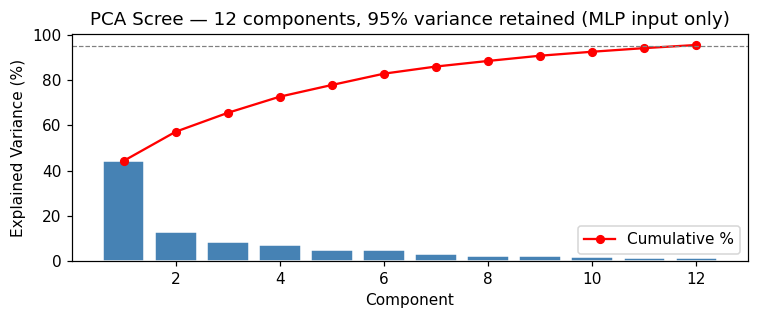

In [11]:
# PCA scree plot
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(1, pca.n_components_+1), pca.explained_variance_ratio_*100,
       color='steelblue', edgecolor='white')
ax.plot(range(1, pca.n_components_+1), np.cumsum(pca.explained_variance_ratio_)*100,
        'ro-', ms=5, label='Cumulative %')
ax.axhline(95, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Component'); ax.set_ylabel('Explained Variance (%)')
ax.set_title(f'PCA Scree — {pca.n_components_} components, 95% variance retained (MLP input only)')
ax.legend(); plt.tight_layout()
plt.savefig('fig_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Training

In [12]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<30s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}')
    return {'Model':name, 'RMSE':round(rmse,3), 'MAE':round(mae,3), 'R2':round(r2,3), 'Time_s':0}

results = []

In [13]:
# Random Forest
t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=SEED, n_jobs=-1)
rf.fit(X_tr_mm, y_tr)
rf_time = round(time.time()-t0, 1)

y_pred_rf = rf.predict(X_te_mm)
r = evaluate('Random Forest', y_te, y_pred_rf)
r['Time_s'] = rf_time; results.append(r)
print(f'  Training time: {rf_time}s')
pickle.dump(rf, open('rf_model.pkl','wb'))

  Random Forest                   RMSE=3.708  MAE=2.597  R²=0.640
  Training time: 0.3s


In [14]:
# XGBoost with early stopping
t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, early_stopping_rounds=20,
    eval_metric='rmse', verbosity=0
)
xgb_model.fit(X_tr_mm, y_tr, eval_set=[(X_va_mm, y_va)], verbose=False)
xgb_time = round(time.time()-t0, 1)

y_pred_xgb = xgb_model.predict(X_te_mm)
r = evaluate('XGBoost', y_te, y_pred_xgb)
r['Time_s'] = xgb_time; results.append(r)
print(f'  Training time: {xgb_time}s  |  Best iteration: {xgb_model.best_iteration}')
pickle.dump(xgb_model, open('xgb_model.pkl','wb'))

  XGBoost                         RMSE=3.886  MAE=2.823  R²=0.604
  Training time: 2.2s  |  Best iteration: 62


LSTM input shape: (500, 7, 19)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
LSTM  RMSE=8.787  MAE=6.510  R2=-0.994
LSTM trained in 6.3s


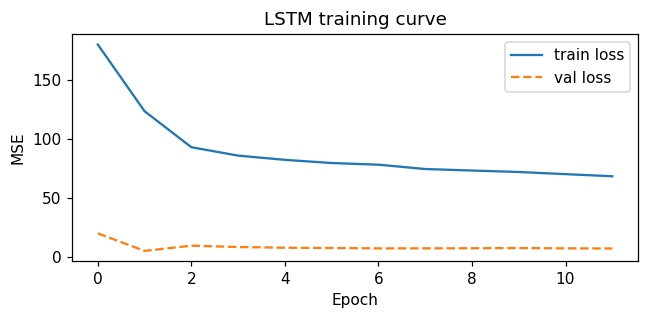

In [15]:
# LSTM is used as the main sequence-based deep learning model.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# reshape input to 3D for LSTM: (samples, timesteps, features)
SEQ_LEN = 7

def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

# use standardised features for LSTM
X_seq_tr, y_seq_tr = make_sequences(X_tr_std, y_tr, SEQ_LEN)
X_seq_va, y_seq_va = make_sequences(X_va_std, y_va, SEQ_LEN)
X_seq_te, y_seq_te = make_sequences(X_te_std, y_te, SEQ_LEN)

print(f'LSTM input shape: {X_seq_tr.shape}')

# build model: 2 LSTM layers + dropout + dense output
tf.random.set_seed(42)
lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X_tr_std.shape[1])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
lstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

t0 = time.time()
history = lstm.fit(
    X_seq_tr, y_seq_tr,
    validation_data=(X_seq_va, y_seq_va),
    epochs=100, batch_size=16,
    callbacks=[early_stop], verbose=0
)
lstm_time = round(time.time()-t0, 1)

y_pred_lstm = lstm.predict(X_seq_te).ravel()
rmse_lstm = np.sqrt(mean_squared_error(y_seq_te, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_seq_te, y_pred_lstm)
r2_lstm   = r2_score(y_seq_te, y_pred_lstm)
print(f'LSTM  RMSE={rmse_lstm:.3f}  MAE={mae_lstm:.3f}  R2={r2_lstm:.3f}')
results.append({'Model':'LSTM', 'RMSE':round(rmse_lstm,3), 
                'MAE':round(mae_lstm,3), 'R2':round(r2_lstm,3), 
                'Time_s': lstm_time})
print(f'LSTM trained in {lstm_time}s')

# training curve
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(history.history['loss'], label='train loss')
ax.plot(history.history['val_loss'], label='val loss', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend()
ax.set_title('LSTM training curve')
plt.tight_layout()
plt.savefig('fig_lstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()

lstm.save("lstm_model.keras")

  MLP Neural Network baseline     RMSE=7.063  MAE=3.600  R²=-0.308
  Training time: 0.7s  |  Iterations: 176


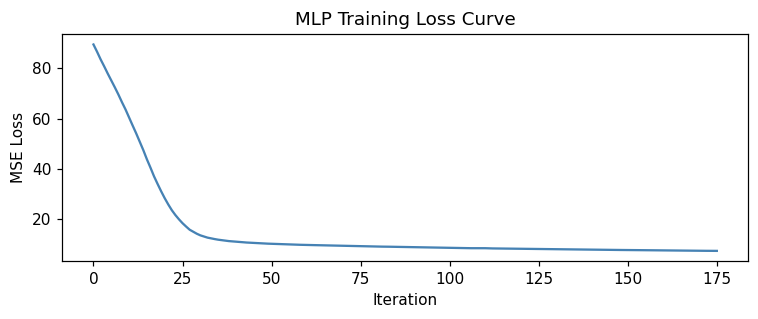

In [16]:
# MLP Neural Network — input: PCA-reduced features (19 → 12 components)
t0 = time.time()
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
    learning_rate_init=0.001, max_iter=500,
    early_stopping=True, validation_fraction=0.15,
    random_state=SEED, verbose=False
)
mlp.fit(X_tr_pca, y_tr)
mlp_time = round(time.time()-t0, 1)

y_pred_mlp = mlp.predict(X_te_pca)
r = evaluate('MLP Neural Network baseline', y_te, y_pred_mlp)
r['Time_s'] = mlp_time; results.append(r)
print(f'  Training time: {mlp_time}s  |  Iterations: {mlp.n_iter_}')

# MLP training loss curve
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(mlp.loss_curve_, color='steelblue', linewidth=1.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('MSE Loss')
ax.set_title('MLP Training Loss Curve')
plt.tight_layout()
plt.savefig('fig_mlp_loss.png', dpi=150, bbox_inches='tight')
plt.show()

pickle.dump(mlp,       open('mlp_model.pkl' ,'wb'))
pickle.dump(mm,        open('mm_scaler.pkl' ,'wb'))
pickle.dump(std,       open('std_scaler.pkl','wb'))
pickle.dump(pca,       open('pca.pkl'       ,'wb'))

In [17]:
# inference latency — average over 100 runs on test set
def inference_latency(model, X_test, n_runs=100, is_keras=False):
    start = time.time()
    for _ in range(n_runs):
        if is_keras:
            _ = model.predict(X_test, verbose=0)
        else:
            _ = model.predict(X_test)
    return round((time.time() - start) / n_runs * 1000, 3)

lat_rf   = inference_latency(rf,        X_te_mm)
lat_xgb  = inference_latency(xgb_model, X_te_mm)
lat_lstm = inference_latency(lstm,      X_seq_te, is_keras=True)
lat_mlp  = inference_latency(mlp,       X_te_pca)

print(f'Inference latency (avg over 100 runs):')
print(f'  RF      : {lat_rf} ms')
print(f'  XGBoost : {lat_xgb} ms')
print(f'  LSTM    : {lat_lstm} ms')
print(f'  MLP     : {lat_mlp} ms')

Inference latency (avg over 100 runs):
  RF      : 41.736 ms
  XGBoost : 0.435 ms
  LSTM    : 77.609 ms
  MLP     : 0.364 ms


## 7. Results & Comparison

In [18]:
results_df = pd.DataFrame(results)
results_df['Latency_ms'] = [lat_rf, lat_xgb, lat_lstm, lat_mlp,]
display(results_df[['Model', 'RMSE', 'MAE', 'R2', 'Time_s', 'Latency_ms']])

,Model,RMSE,MAE,R2,Time_s,Latency_ms
0,Random Forest,3.708,2.597,0.640,0.3,41.736
1,XGBoost,3.886,2.823,0.604,2.2,0.435
2,LSTM,8.787,6.510,-0.994,6.3,77.609
3,MLP Neural Network baseline,7.063,3.600,-0.308,0.7,0.364


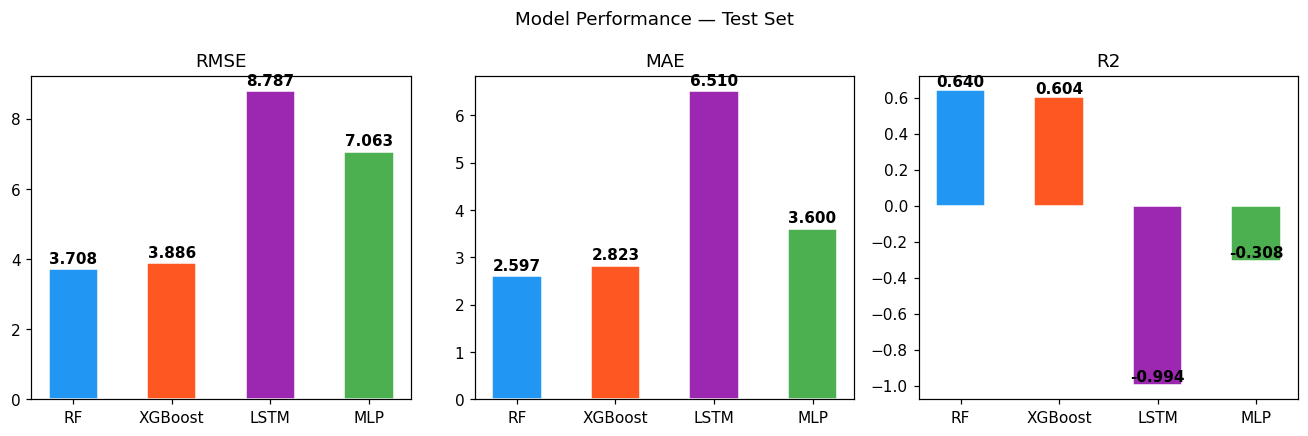

In [19]:
# Performance bar charts
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels = ['RF', 'XGBoost', 'LSTM', 'MLP']
clrs   = ['#2196F3', '#FF5722', '#9C27B0', '#4CAF50']
for ax, metric in zip(axes, ['RMSE','MAE','R2']):
    vals = results_df[metric].values
    bars = ax.bar(labels, vals, color=clrs, edgecolor='white', width=0.5)
    ax.set_title(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02*max(abs(vals)),
                f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Model Performance — Test Set')
plt.tight_layout()
plt.savefig('fig_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

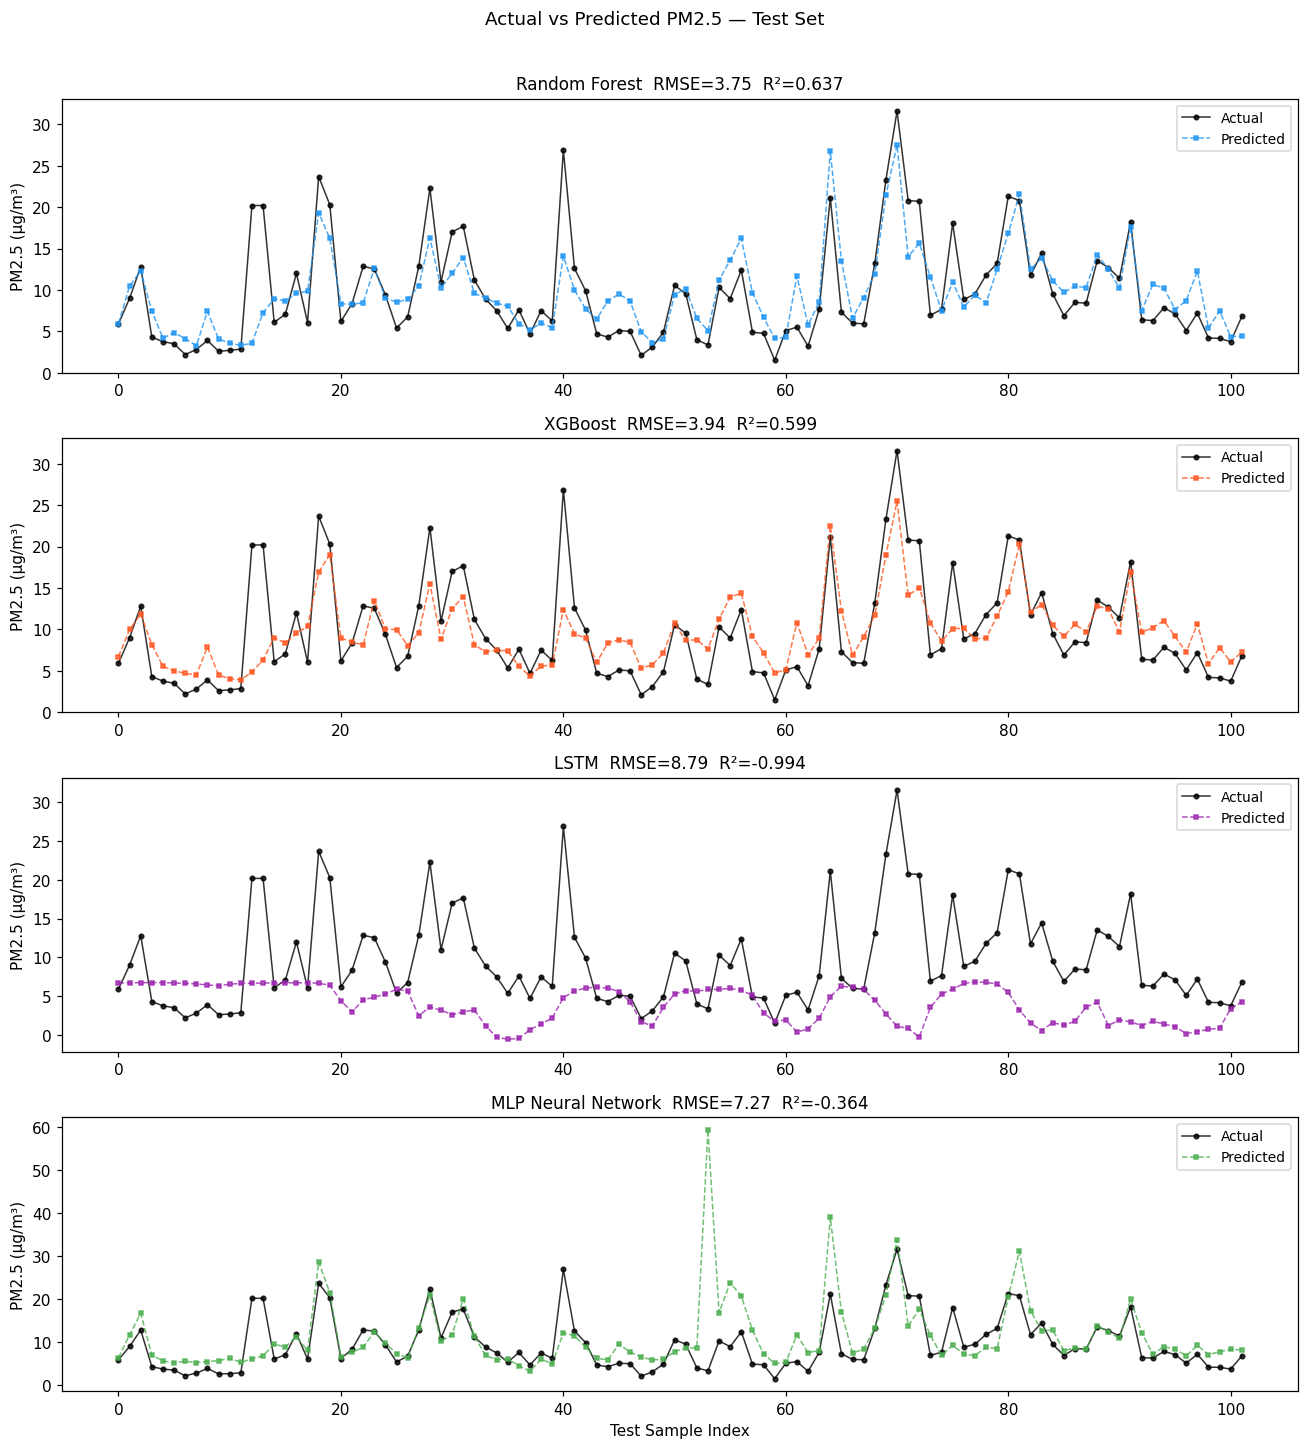

In [20]:
# Actual vs Predicted
y_te_al  = y_te[-len(y_seq_te):]
rf_al    = rf.predict(X_te_mm[-len(y_seq_te):])
xgb_al   = xgb_model.predict(X_te_mm[-len(y_seq_te):])
mlp_al   = mlp.predict(X_te_pca[-len(y_seq_te):])

fig, axes = plt.subplots(4, 1, figsize=(12, 13))
for ax, (name, pred, clr) in zip(axes, [
    ('Random Forest',      rf_al,        '#2196F3'),
    ('XGBoost',            xgb_al,       '#FF5722'),
    ('LSTM',               y_pred_lstm,  '#9C27B0'),
    ('MLP Neural Network', mlp_al,       '#4CAF50'),
]):
    rmse = np.sqrt(mean_squared_error(y_te_al, pred))
    r2   = r2_score(y_te_al, pred)
    ax.plot(y_te_al, 'o-', color='black', ms=3, lw=1, label='Actual',    alpha=0.8)
    ax.plot(pred,    's--', color=clr,    ms=3, lw=1, label='Predicted', alpha=0.8)
    ax.set_title(f'{name}  RMSE={rmse:.2f}  R²={r2:.3f}', fontsize=11)
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Test Sample Index')
plt.suptitle('Actual vs Predicted PM2.5 — Test Set', y=1.01)
plt.tight_layout()
plt.savefig('fig_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# aligned comparison — all 4 models on same 102 test samples
aligned_results = []
for name, pred in [
    ('Random Forest', rf_al),
    ('XGBoost',       xgb_al),
    ('LSTM',          y_pred_lstm),
    ('MLP',           mlp_al)
]:
    rmse = np.sqrt(mean_squared_error(y_te_al, pred))
    mae  = mean_absolute_error(y_te_al, pred)
    r2   = r2_score(y_te_al, pred)
    aligned_results.append({'Model':name,'RMSE':round(rmse,3),'MAE':round(mae,3),'R2':round(r2,3)})

display(pd.DataFrame(aligned_results))

,Model,RMSE,MAE,R2
0,Random Forest,3.748,2.639,0.637
1,XGBoost,3.939,2.890,0.599
2,LSTM,8.787,6.510,-0.994
3,MLP,7.268,3.725,-0.364


## 8. SHAP Explainability

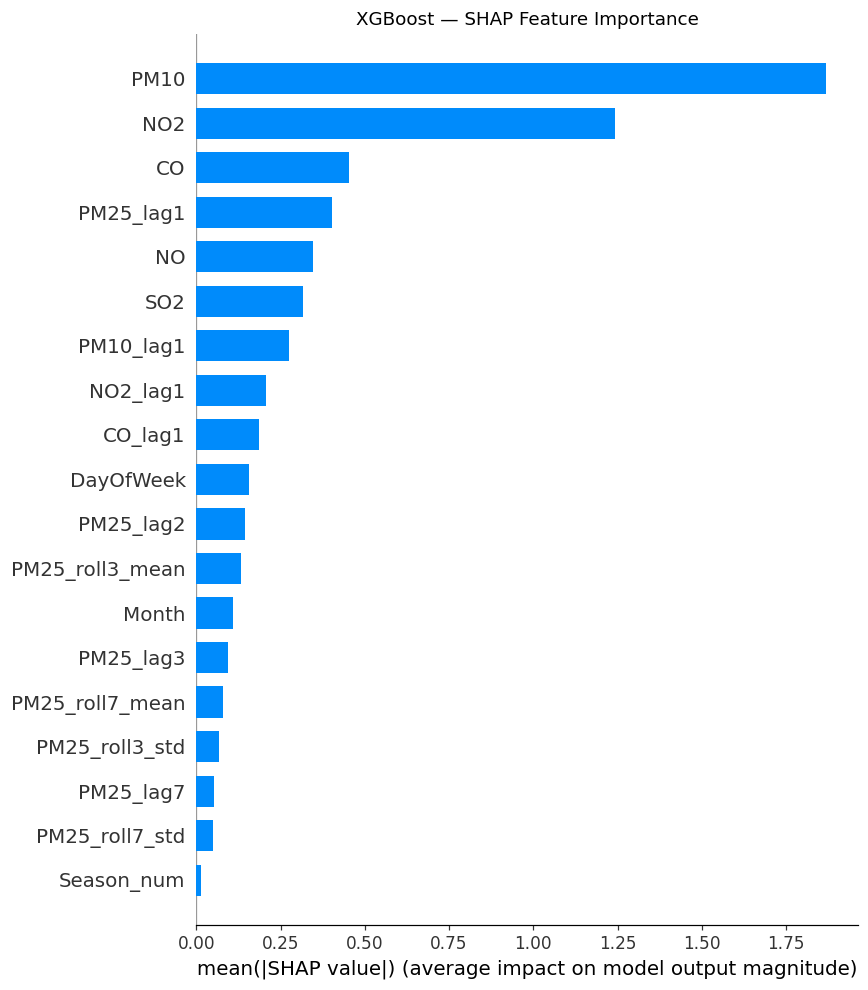

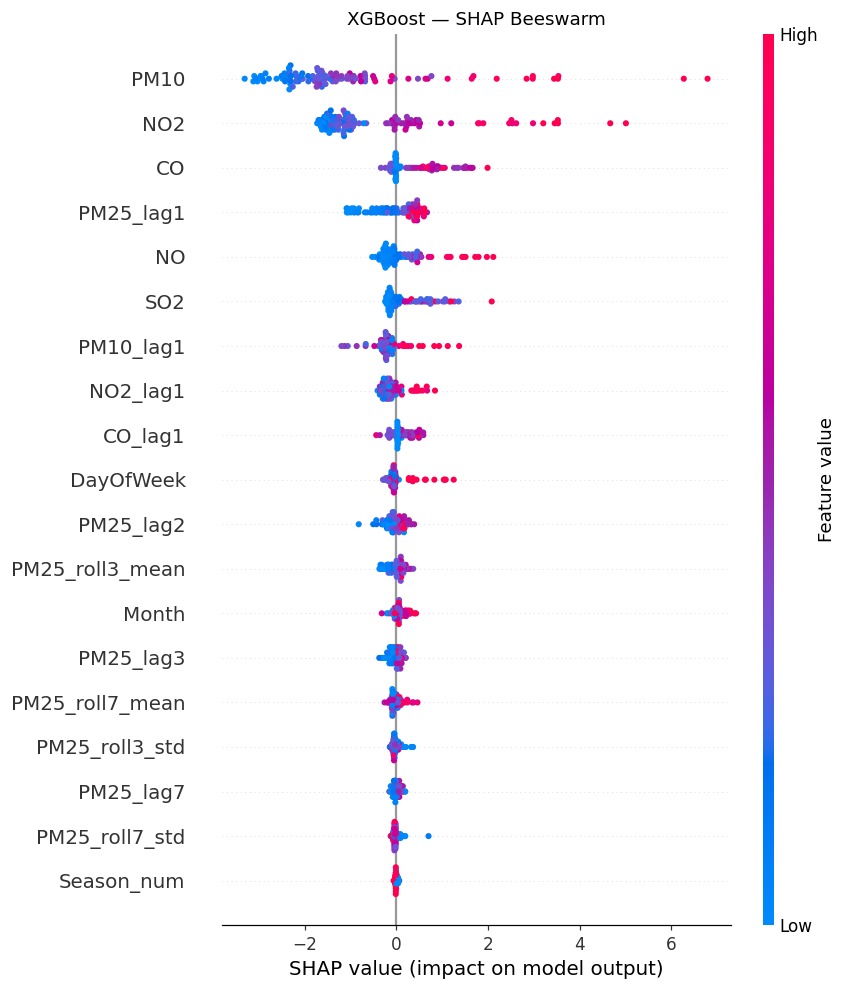

In [22]:
# XGBoost SHAP — exact Shapley values via TreeExplainer on original feature space
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_vals_xgb = explainer_xgb.shap_values(X_te_mm)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_vals_xgb, X_te_mm, feature_names=FEAT_COLS, plot_type='bar', show=False)
plt.title('XGBoost — SHAP Feature Importance')
plt.tight_layout()
plt.savefig('fig_shap_xgb_bar.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals_xgb, X_te_mm, feature_names=FEAT_COLS, show=False)
plt.title('XGBoost — SHAP Beeswarm')
plt.tight_layout()
plt.savefig('fig_shap_xgb_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

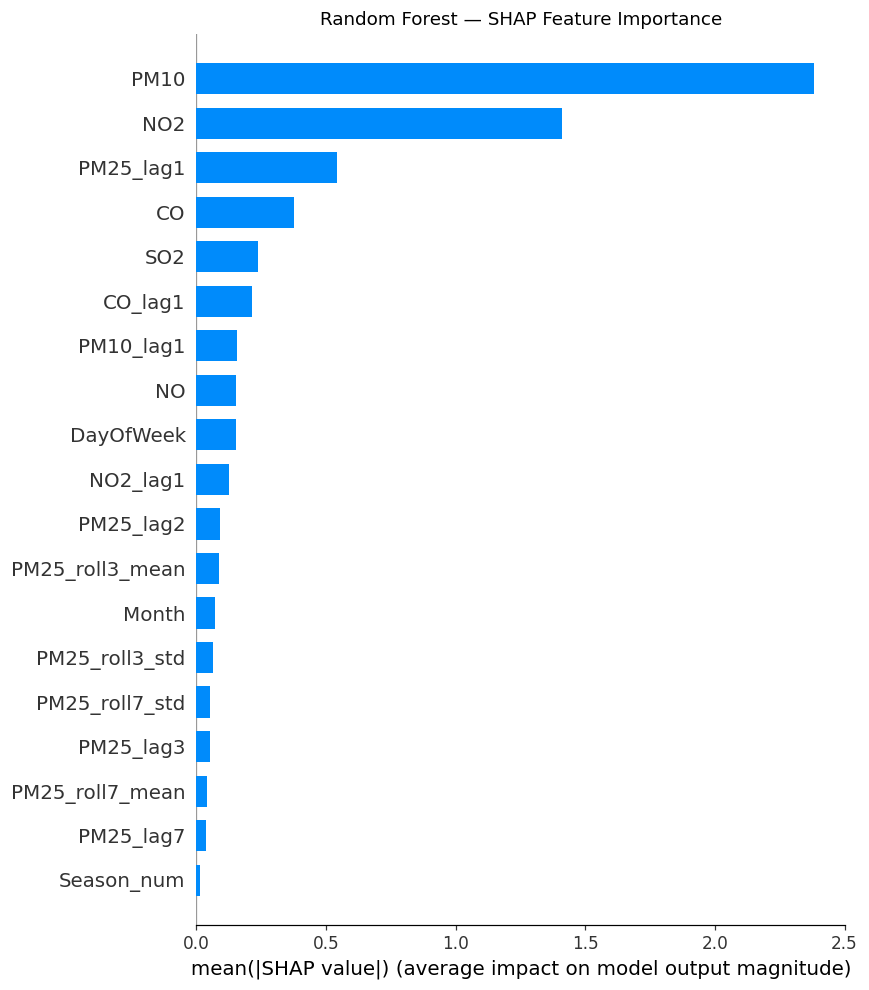

In [23]:
# Random Forest SHAP
explainer_rf = shap.TreeExplainer(rf)
shap_vals_rf = explainer_rf.shap_values(X_te_mm)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_vals_rf, X_te_mm, feature_names=FEAT_COLS, plot_type='bar', show=False)
plt.title('Random Forest — SHAP Feature Importance')
plt.tight_layout()
plt.savefig('fig_shap_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Ablation Study — Multi-Pollutant vs PM2.5

Multi-pollutant RMSE : 3.886 µg/m³
PM2.5-only RMSE      : 5.345 µg/m³
Improvement          : 1.458 µg/m³  (27.3% reduction)


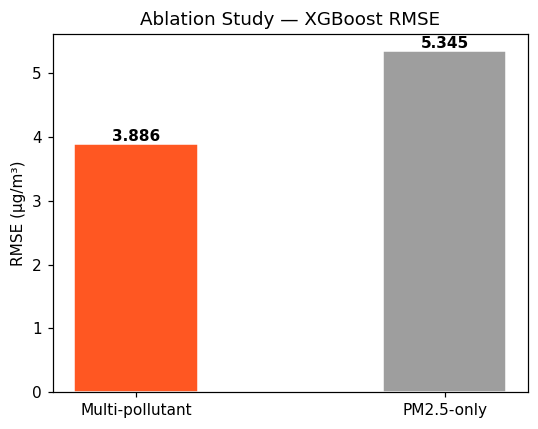

In [24]:
# Train XGBoost with PM2.5-only features and compare RMSE
pm25_only = [c for c in FEAT_COLS if c.startswith('PM25') or c in ['DayOfWeek','Month','Season_num']]
idx = [FEAT_COLS.index(c) for c in pm25_only]

xgb_ab = xgb.XGBRegressor(
    n_estimators=max(1, xgb_model.best_iteration + 1), learning_rate=0.05,
    max_depth=6, subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, verbosity=0
)
xgb_ab.fit(X_tr_mm[:, idx], y_tr)
y_pred_ab = xgb_ab.predict(X_te_mm[:, idx])

rmse_multi = np.sqrt(mean_squared_error(y_te, y_pred_xgb))
rmse_pm25  = np.sqrt(mean_squared_error(y_te, y_pred_ab))
print(f'Multi-pollutant RMSE : {rmse_multi:.3f} µg/m³')
print(f'PM2.5-only RMSE      : {rmse_pm25:.3f} µg/m³')
print(f'Improvement          : {rmse_pm25-rmse_multi:.3f} µg/m³  ({(rmse_pm25-rmse_multi)/rmse_pm25*100:.1f}% reduction)')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Multi-pollutant', 'PM2.5-only'], [rmse_multi, rmse_pm25],
       color=['#FF5722','#9E9E9E'], width=0.4, edgecolor='white')
ax.set_ylabel('RMSE (µg/m³)')
ax.set_title('Ablation Study — XGBoost RMSE')
for i, v in enumerate([rmse_multi, rmse_pm25]):
    ax.text(i, v+0.05, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Learning Curves & Error Analysis

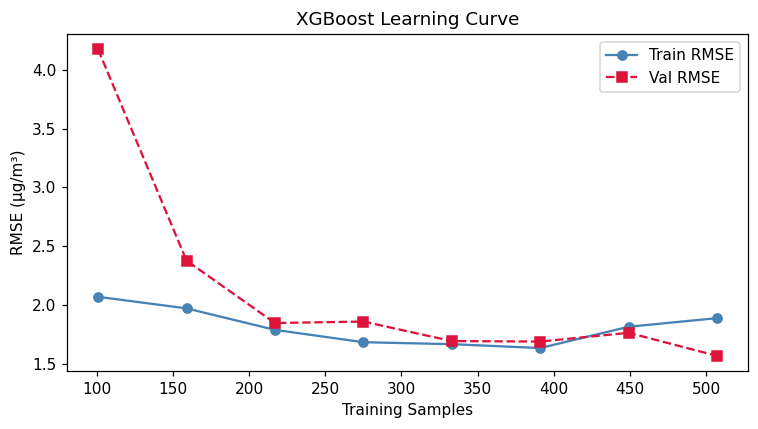

In [25]:
# XGBoost learning curve
fracs = np.linspace(0.2, 1.0, 8)
lc_tr, lc_va = [], []
for frac in fracs:
    n_use = max(20, int(len(X_tr_mm)*frac))
    m = xgb.XGBRegressor(n_estimators=max(1, xgb_model.best_iteration + 1), learning_rate=0.05,
                          max_depth=6, subsample=0.8, colsample_bytree=0.8,
                          random_state=SEED, verbosity=0)
    m.fit(X_tr_mm[:n_use], y_tr[:n_use])
    lc_tr.append(np.sqrt(mean_squared_error(y_tr[:n_use], m.predict(X_tr_mm[:n_use]))))
    lc_va.append(np.sqrt(mean_squared_error(y_va,         m.predict(X_va_mm))))

ns = [int(len(X_tr_mm)*f) for f in fracs]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, lc_tr, 'o-',  color='steelblue', label='Train RMSE')
ax.plot(ns, lc_va, 's--', color='crimson',   label='Val RMSE')
ax.set_xlabel('Training Samples'); ax.set_ylabel('RMSE (µg/m³)')
ax.set_title('XGBoost Learning Curve'); ax.legend()
plt.tight_layout()
plt.savefig('fig_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

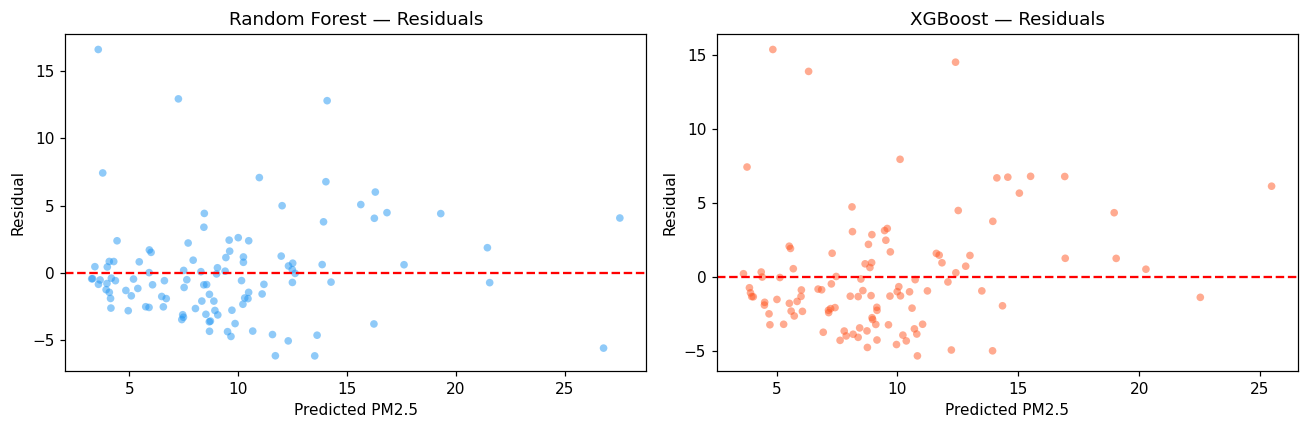

In [26]:
# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, pred, clr) in zip(axes, [
    ('Random Forest', y_pred_rf,  '#2196F3'),
    ('XGBoost',       y_pred_xgb, '#FF5722')
]):
    ax.scatter(pred, y_te-pred, alpha=0.5, color=clr, s=25, edgecolors='none')
    ax.axhline(0, color='red', lw=1.5, linestyle='--')
    ax.set_xlabel('Predicted PM2.5'); ax.set_ylabel('Residual')
    ax.set_title(f'{name} — Residuals')
plt.tight_layout()
plt.savefig('fig_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Peak error analysis (above 90th percentile)
threshold = np.percentile(y_te, 90)
peak = y_te > threshold
print(f'90th percentile threshold: {threshold:.2f} µg/m³  |  Peak samples: {peak.sum()}')
print(f'{"Model":<22}  {"Peak RMSE":>12}  {"Normal RMSE":>12}')
print('-' * 50)
for name, pred in [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]:
    pk = np.sqrt(mean_squared_error(y_te[peak],  pred[peak]))
    nm = np.sqrt(mean_squared_error(y_te[~peak], pred[~peak]))
    print(f'{name:<22}  {pk:>12.3f}  {nm:>12.3f}')

90th percentile threshold: 20.22 µg/m³  |  Peak samples: 11
Model                      Peak RMSE   Normal RMSE
--------------------------------------------------
Random Forest                  5.877         3.378
XGBoost                        6.636         3.443


In [28]:
print(results_df)

                         Model   RMSE    MAE     R2  Time_s  Latency_ms
0                Random Forest  3.708  2.597  0.640     0.3      41.736
1                      XGBoost  3.886  2.823  0.604     2.2       0.435
2                         LSTM  8.787  6.510 -0.994     6.3      77.609
3  MLP Neural Network baseline  7.063  3.600 -0.308     0.7       0.364
